<a href="https://colab.research.google.com/github/priyanka22wh1a1264/DataAnalysis/blob/main/LinearRegression_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression

In [257]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [258]:
df=pd.read_csv("/content/taxi_trip_pricing (1).csv")
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


**Handling missing values**

In [260]:
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [261]:
df["Trip_Distance_km"].unique()

array([ 19.35      ,  47.59      ,  36.87      ,  30.33      ,
                nan,   8.64      ,   3.85      ,  43.44      ,
        30.45      ,  35.7       ,  48.53      ,  41.79      ,
        11.4       ,   9.91      ,   9.99      ,  15.91      ,
        26.71      ,  22.17      ,  15.27      ,  30.98      ,
         7.84      , 105.94355004,  18.95      ,  23.35      ,
        39.47      ,  10.78      , 138.09832791,  30.03      ,
         3.28      ,  30.77      ,   9.36      ,   4.19      ,
        47.5       ,  48.32      ,  40.61      ,  15.93      ,
         5.79      ,  34.53      ,  22.57      ,   6.98      ,
        25.26      ,   2.69      ,  45.56      ,  13.68      ,
        33.46      ,  16.27      ,  26.48      ,  27.79      ,
        10.06      ,  48.51      ,  38.98      ,  47.04      ,
        44.85      ,  30.3       ,  46.17      ,   5.34      ,
        10.6       ,   3.22      ,  16.94      ,  20.05      ,
        14.3       ,  41.61      ,  18.48      , 146.06

In [262]:
df[df["Trip_Distance_km"].isnull()]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
10,NaN,Morning,Weekday,4.0,NaN,Clear,2.40,0.58,0.43,26.34,14.8920
84,NaN,Night,Weekday,1.0,Medium,Clear,3.38,1.50,0.31,58.31,45.8161
87,NaN,NaN,Weekday,1.0,Medium,Clear,3.41,0.57,0.39,92.72,57.9476
95,NaN,Morning,Weekend,1.0,Medium,Clear,3.43,0.91,0.50,67.43,60.0770
111,NaN,Morning,Weekday,2.0,Low,Clear,4.01,1.65,0.17,109.77,37.3559
134,NaN,Afternoon,Weekend,3.0,Low,Clear,2.55,1.46,0.37,38.26,85.6182
137,NaN,NaN,NaN,3.0,Low,Clear,4.52,1.38,0.35,57.56,73.5870
142,NaN,Afternoon,Weekend,4.0,Medium,Rain,2.98,1.24,0.28,36.68,44.7092
166,NaN,Evening,Weekday,2.0,High,Clear,4.11,1.00,0.36,86.31,51.9016


In [263]:
#replacing nan values with median
med=df["Trip_Distance_km"].median()
df["Trip_Distance_km"]=df["Trip_Distance_km"].fillna(med)
df.info()
df["Trip_Distance_km"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


array([ 19.35      ,  47.59      ,  36.87      ,  30.33      ,
        25.83      ,   8.64      ,   3.85      ,  43.44      ,
        30.45      ,  35.7       ,  48.53      ,  41.79      ,
        11.4       ,   9.91      ,   9.99      ,  15.91      ,
        26.71      ,  22.17      ,  15.27      ,  30.98      ,
         7.84      , 105.94355004,  18.95      ,  23.35      ,
        39.47      ,  10.78      , 138.09832791,  30.03      ,
         3.28      ,  30.77      ,   9.36      ,   4.19      ,
        47.5       ,  48.32      ,  40.61      ,  15.93      ,
         5.79      ,  34.53      ,  22.57      ,   6.98      ,
        25.26      ,   2.69      ,  45.56      ,  13.68      ,
        33.46      ,  16.27      ,  26.48      ,  27.79      ,
        10.06      ,  48.51      ,  38.98      ,  47.04      ,
        44.85      ,  30.3       ,  46.17      ,   5.34      ,
        10.6       ,   3.22      ,  16.94      ,  20.05      ,
        14.3       ,  41.61      ,  18.48      , 146.06

In [264]:
#replacing nan values in Time_of_Day col with mode
df["Time_of_Day"].unique()
mode=df["Time_of_Day"].mode()[0]
df["Time_of_Day"]=df["Time_of_Day"].fillna(mode)
df["Time_of_Day"].unique()


array(['Morning', 'Afternoon', 'Evening', 'Night'], dtype=object)

In [265]:
#replacing nan values in day_of_week col with mode
df["Day_of_Week"].unique()
mode=df["Day_of_Week"].mode()[0]
df["Day_of_Week"]=df["Day_of_Week"].fillna(mode)
df["Day_of_Week"].unique()


array(['Weekday', 'Weekend'], dtype=object)

In [266]:
#replacing nan values in Passenger_Count with median and converting it to int
df["Passenger_Count"].unique()
med = df["Passenger_Count"].median()
df["Passenger_Count"] = df["Passenger_Count"].fillna(med)
df["Passenger_Count"]=df["Passenger_Count"].astype(int)
df["Passenger_Count"].unique()

array([3, 1, 4, 2])

In [267]:
#replacing nan values in Traffic_Conditions with mode
df["Traffic_Conditions"].unique()
df["Traffic_Conditions"]
mode= df["Traffic_Conditions"].mode()[0]
df["Traffic_Conditions"] = df["Traffic_Conditions"].fillna(mode)
df["Traffic_Conditions"].unique()


array(['Low', 'High', 'Medium'], dtype=object)

In [268]:
#replacing nan values in weather col with mode
df["Weather"].unique()
mode= df["Weather"].mode()[0]
df["Weather"] = df["Weather"].fillna(mode)
df["Weather"].unique()



array(['Clear', 'Rain', 'Snow'], dtype=object)

In [269]:
#replacing nan values in Base_Fare with mean
df["Base_Fare"].unique()
mean= df["Base_Fare"].mean()
df["Base_Fare"] = df["Base_Fare"].fillna(mean)
df["Base_Fare"].unique()

array([3.56      , 3.50298947, 2.7       , 3.48      , 2.93      ,
       2.55      , 3.51      , 2.97      , 2.77      , 3.39      ,
       2.4       , 4.78      , 4.6       , 4.12      , 2.32      ,
       4.33      , 4.42      , 4.3       , 2.34      , 3.93      ,
       4.5       , 3.73      , 3.94      , 3.38      , 3.59      ,
       3.92      , 2.24      , 3.31      , 2.88      , 3.64      ,
       4.07      , 4.39      , 2.49      , 2.31      , 2.44      ,
       4.63      , 3.58      , 3.4       , 3.95      , 3.88      ,
       2.23      , 2.15      , 2.41      , 3.16      , 4.83      ,
       3.83      , 4.13      , 4.21      , 2.83      , 3.02      ,
       4.99      , 2.79      , 2.84      , 4.79      , 2.07      ,
       4.09      , 4.18      , 4.51      , 4.92      , 4.93      ,
       2.2       , 4.47      , 2.39      , 4.95      , 4.74      ,
       3.32      , 2.12      , 3.09      , 4.48      , 4.1       ,
       2.17      , 3.28      , 3.41      , 3.08      , 3.43   

In [270]:
#replacing nan values in Per_Km_Rate col with median
df["Per_Km_Rate"].unique()
med = df["Per_Km_Rate"].median()
df["Per_Km_Rate"] = df["Per_Km_Rate"].fillna(med)
df["Per_Km_Rate"].unique()

array([0.8 , 0.62, 1.21, 0.51, 0.63, 1.71, 1.66, 1.87, 1.78, 1.52, 0.58,
       1.22, 1.77, 1.26, 0.85, 1.59, 1.97, 0.73, 0.84, 0.82, 1.69, 0.78,
       0.6 , 0.54, 1.75, 1.05, 1.76, 1.33, 1.85, 1.89, 0.61, 0.88, 1.5 ,
       1.83, 1.41, 1.95, 0.9 , 1.25, 0.72, 1.16, 1.  , 1.28, 1.38, 1.64,
       1.57, 1.63, 1.93, 0.86, 0.99, 1.37, 1.03, 1.55, 1.34, 1.08, 1.13,
       1.82, 1.56, 1.88, 0.91, 1.35, 1.91, 1.61, 1.12, 0.57, 0.79, 1.18,
       0.95, 1.62, 0.68, 1.3 , 1.39, 0.69, 1.31, 1.9 , 0.96, 1.8 , 1.65,
       0.87, 0.55, 0.65, 1.06, 0.67, 1.11, 1.23, 1.73, 0.76, 1.54, 0.71,
       1.29, 1.46, 1.01, 1.86, 1.17, 1.24, 1.84, 1.53, 1.79, 0.98, 0.77,
       0.7 , 0.94, 1.36, 1.02, 0.59, 1.45, 1.48, 0.52, 1.32, 0.83, 1.7 ,
       1.49, 1.07, 1.19, 1.74, 1.14, 1.94, 0.74, 1.92, 1.99, 0.93, 0.5 ,
       2.  , 0.92, 0.75, 1.81, 1.98, 0.97, 1.1 , 1.2 , 1.15, 1.96, 1.72,
       1.51, 1.27, 1.43, 1.4 , 1.67, 0.53, 1.44, 1.09, 0.81, 1.04, 0.56,
       1.47, 0.89, 1.42, 0.64, 1.68, 1.58, 0.66])

In [271]:
#replacing nan values in Per_Minute_Rate col with mean
df["Per_Minute_Rate"].unique()
mean= df["Per_Minute_Rate"].mean()
df["Per_Minute_Rate"] = df["Per_Minute_Rate"].fillna(mean)
df["Per_Minute_Rate"].unique()

array([0.32      , 0.43      , 0.15      , 0.48      , 0.29291579,
       0.23      , 0.34      , 0.47      , 0.5       , 0.11      ,
       0.21      , 0.2       , 0.41      , 0.12      , 0.25      ,
       0.3       , 0.39      , 0.24      , 0.35      , 0.33      ,
       0.36      , 0.13      , 0.19      , 0.44      , 0.38      ,
       0.42      , 0.26      , 0.18      , 0.17      , 0.29      ,
       0.28      , 0.31      , 0.37      , 0.46      , 0.16      ,
       0.4       , 0.1       , 0.27      , 0.49      , 0.45      ,
       0.14      , 0.22      ])

In [272]:
#replacing nan values in Trip_Duration_Minutes col with median
df["Trip_Duration_Minutes"].unique()
median= df["Trip_Duration_Minutes"].median()
df["Trip_Duration_Minutes"] = df["Trip_Duration_Minutes"].fillna(median)
df["Trip_Duration_Minutes"].unique()

array([ 53.82,  40.57,  37.27, 116.81,  22.64,  89.33,   5.05,  61.86,
       110.33,  26.34,  79.94,  86.95,  84.12,  41.72,  34.  , 114.93,
       111.18,  57.59,  57.02,  53.8 ,  23.03,  54.04,  66.8 ,   7.59,
        56.07,  94.86,  83.21,  78.04, 109.6 ,   7.07,  69.06,  95.55,
        67.25,  42.25,  20.67, 107.07,  59.14, 105.98,  72.37,  82.53,
        97.49,  80.8 ,  50.78,  64.07,  97.35,  47.97,  49.63,  16.  ,
       110.18,  15.47,  79.54,  52.52,  51.65,  83.15,  12.72,  73.28,
        93.78, 100.24,  24.61, 108.2 , 106.41,  60.81,  67.33, 110.69,
       108.49,  56.54,  36.56,  50.21,  49.59,  37.99,  35.89, 104.02,
        13.03,  82.93,  24.87,  44.62,  12.08,  36.05,  93.37, 106.78,
        30.48,  58.31,  59.09, 105.46,  92.72,  64.  ,  82.14, 102.45,
         6.1 ,  51.33, 109.33,  90.14,  67.43,  65.91,  44.99,  80.37,
        53.11,  87.13, 104.04,  22.79,  56.93,  51.92,  84.06,  33.73,
        78.63, 105.91,  53.09, 109.77, 119.21,  17.2 ,  31.8 , 114.29,
      

In [273]:
#replacing nan values in Trip_Price col with median
df["Trip_Price"].unique()
median= df["Trip_Price"].median()
df["Trip_Price"]=df["Trip_Price"].fillna(median)

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            1000 non-null   object 
 2   Day_of_Week            1000 non-null   object 
 3   Passenger_Count        1000 non-null   int64  
 4   Traffic_Conditions     1000 non-null   object 
 5   Weather                1000 non-null   object 
 6   Base_Fare              1000 non-null   float64
 7   Per_Km_Rate            1000 non-null   float64
 8   Per_Minute_Rate        1000 non-null   float64
 9   Trip_Duration_Minutes  1000 non-null   float64
 10  Trip_Price             1000 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 86.1+ KB


In [275]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
for col in df.columns:
  if df[col].dtype==object:
    df[col]=encoder.fit_transform(df[col])
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,2,0,3,1,0,3.560000,0.80,0.32,53.82,36.2624
1,47.59,0,0,1,0,0,3.502989,0.62,0.43,40.57,50.0745
2,36.87,1,1,1,0,0,2.700000,1.21,0.15,37.27,52.9032
3,30.33,1,0,4,1,0,3.480000,0.51,0.15,116.81,36.4698
4,25.83,1,0,3,0,0,2.930000,0.63,0.32,22.64,15.6180


<Axes: >

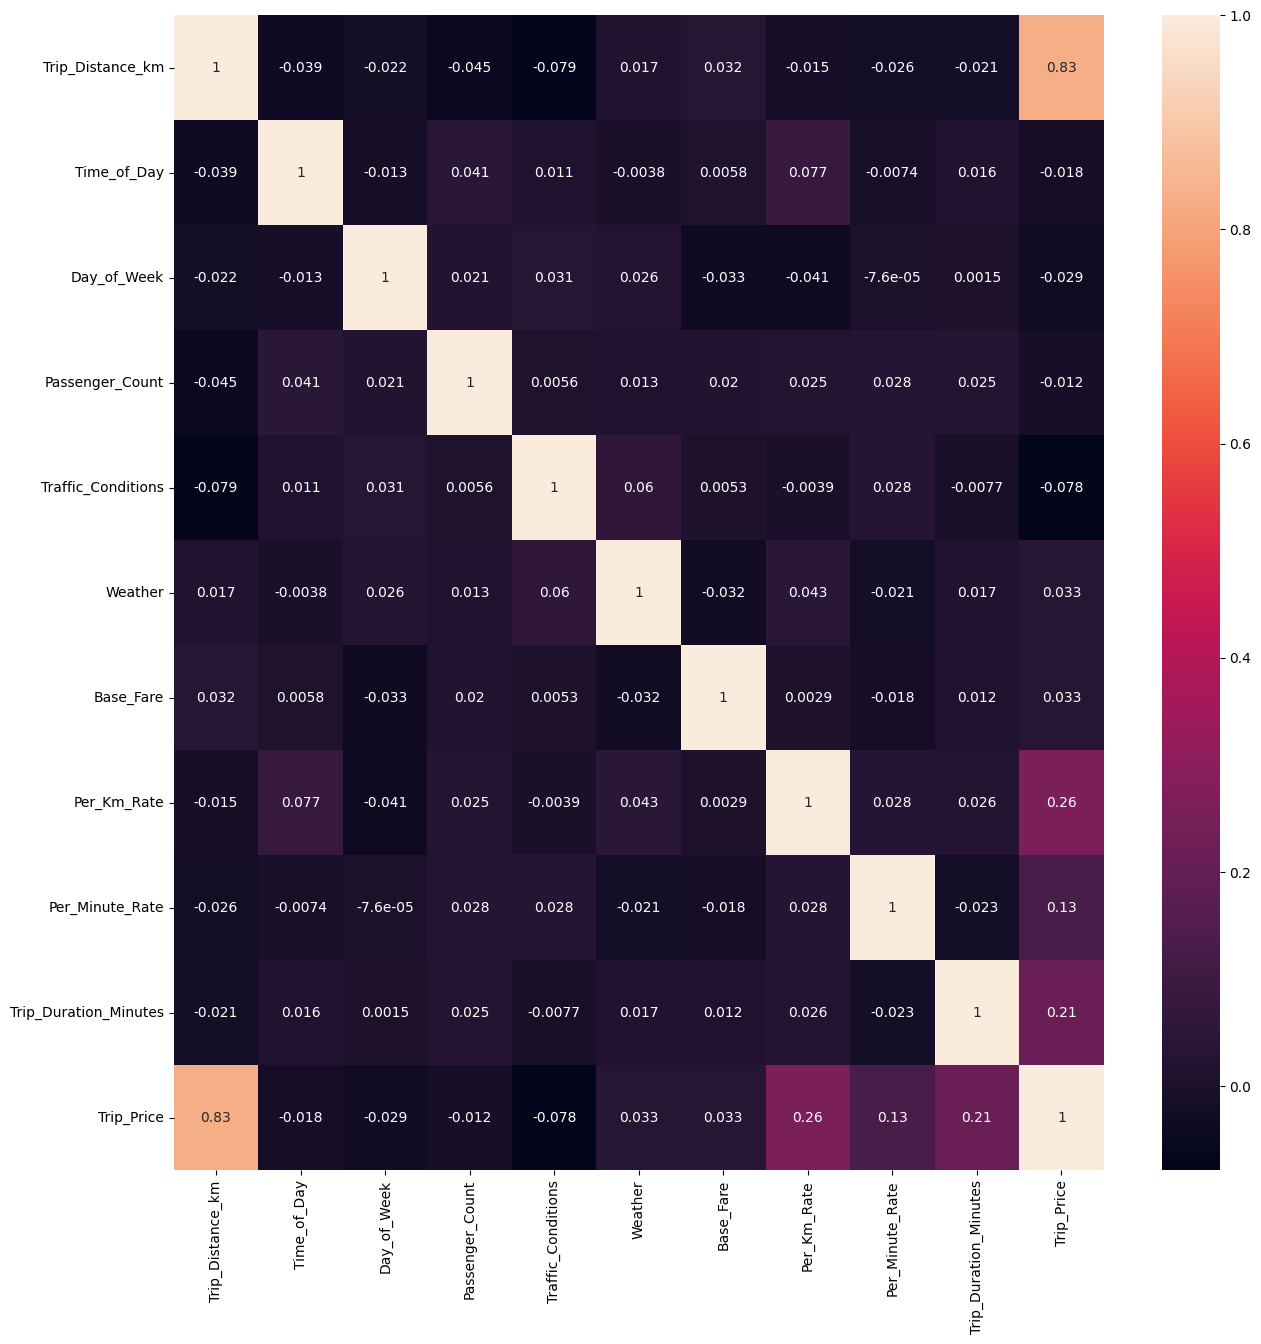

In [276]:
data=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(data,annot=True)

Trip_Distance_km has the strongest correlation with Trip_Price

Time_of_Day, Day_of_Week, Passenger_Count, Weather, and Base_Fare do not strongly influence the trip price

<Axes: xlabel='Trip_Price', ylabel='Count'>

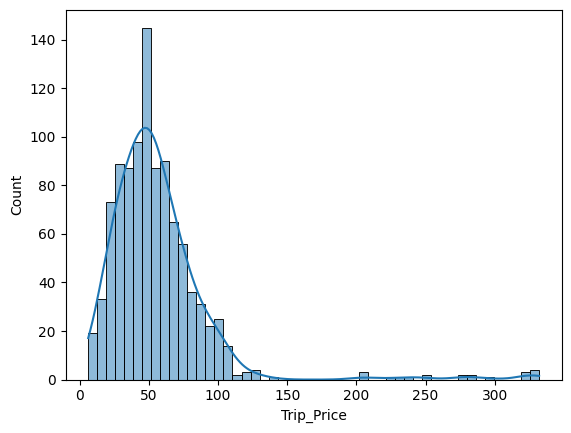

In [277]:
sns.histplot(df['Trip_Price'], kde=True)

Most trip prices are between 20 and 80

Very high prices are rare


<Axes: xlabel='Trip_Distance_km', ylabel='Trip_Price'>

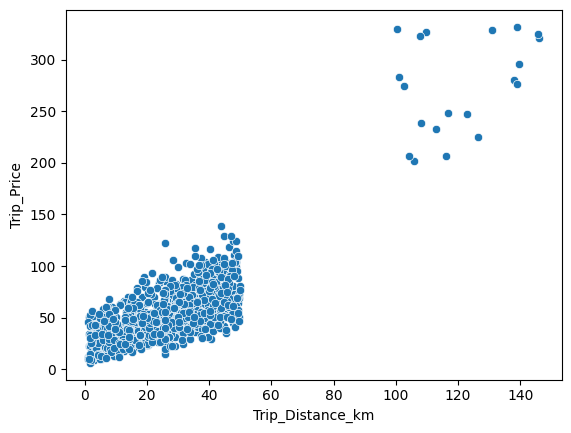

In [278]:
sns.scatterplot(x='Trip_Distance_km', y='Trip_Price', data=df)

Trip price increases as trip distance increases.

Most trips are between 0 to 50 km showing that short-distance trips are more common

Few trips between 100 to 150 km have very high prices indicating long-distance trips

#Model training

In [279]:
#divide the data into i/p and o/p
x=df.drop("Trip_Price",axis=1)
y=df["Trip_Price"]
y

,Trip_Price
0,36.2624
1,50.0745
2,52.9032
3,36.4698
4,15.6180
...,...
995,34.4049
996,62.1295
997,33.1236
998,61.2090


In [280]:
#split data into training and testing data
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [281]:
# from sklearn.preprocessing import StandardScaler
# sc=StandardScaler()
# xtrain=sc.fit_transform(xtrain)
# xtest=sc.transform(xtest)

In [282]:
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,2,0,3,1,0,3.560000,0.80,0.320000,53.82,36.2624
1,47.59,0,0,1,0,0,3.502989,0.62,0.430000,40.57,50.0745
2,36.87,1,1,1,0,0,2.700000,1.21,0.150000,37.27,52.9032
3,30.33,1,0,4,1,0,3.480000,0.51,0.150000,116.81,36.4698
4,25.83,1,0,3,0,0,2.930000,0.63,0.320000,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,0,1,4,2,0,2.390000,0.62,0.490000,58.39,34.4049
996,45.95,3,0,4,2,0,3.120000,0.61,0.292916,61.96,62.1295
997,7.70,2,0,3,1,1,2.080000,1.78,0.292916,54.18,33.1236
998,47.56,2,0,1,1,0,2.670000,0.82,0.170000,114.94,61.2090


In [283]:
#model training
model=LinearRegression()
model.fit(xtrain,ytrain)


LinearRegression()

In [284]:
print("intercept:",model.intercept_)
print("slope:",model.coef_)

intercept: -56.876754876544126
slope: [ 1.72454369 -0.38430376  0.09085036 -0.05605447  0.21324559  1.332965
  0.89242688 24.43442963 51.95435302  0.28493403]


#Model Prediction

In [285]:
ypred=model.predict(xtest)
ypred

array([ 7.51605525e+01,  8.74950063e+01,  6.52492075e+01,  7.28559199e+01,
        1.17658546e+02,  7.21921936e+01,  2.43143064e+01,  5.28700751e+01,
        3.01169278e+01,  7.65362858e+01,  7.38077801e+01,  1.00355761e+02,
        7.37594252e+01,  2.63479321e+01, -4.62470814e-01,  5.45124851e+00,
        6.95168025e+01,  1.76649895e+01,  2.18961785e+01,  3.64412503e+01,
        7.81823354e+01,  3.94607280e+01, -2.50396278e+01,  3.37103106e+01,
        4.31413650e+01,  9.12787430e+01,  6.93685555e+01,  4.34440340e+01,
        3.50383123e+01,  9.27672486e+01,  8.36792920e+01,  8.59982809e+01,
        1.41312050e+01,  1.04312967e+02,  3.94859028e+01,  9.48491186e+01,
        2.32808203e+01,  5.63003438e+01,  2.56803243e+01,  7.63006509e+01,
        5.11482964e+01,  3.70536860e+01,  2.40504630e-01,  3.24949484e+01,
        1.36813355e+01,  6.06359648e+01,  5.29827748e+01,  4.52126853e+01,
        4.08668259e+01,  4.81205275e+01,  6.29348760e+01,  8.70356524e+00,
        8.41174444e+01,  

#Model evaluation

**Performance metrics**

In [286]:
print("metrics :")
r2=r2_score(ytest,ypred)
print("r2 score:",r2)
n=df.shape[0]
p=df.shape[1]
n,p
adjr2=1-(((1-r2**2)*(n-1))/(n-p-1))
print("adjusted r2 score :",adjr2)
#error
print("mean_squared_error :",mean_squared_error(ytest,ypred))
print("mean_absolute_error :",mean_absolute_error(ytest,ypred))

metrics :
r2 score: 0.7805610088260505
adjusted r2 score : 0.6049253168127957
mean_squared_error : 285.86367229506385
mean_absolute_error : 10.293050597949657


In [287]:
print("training efficiency :", model.score(xtrain,ytrain))
print("testing efficiency :", model.score(xtest,ytest))

training efficiency : 0.8533063907559133
testing efficiency : 0.7805610088260505


It is a generalized model, the difference between training and testing efficiency is very small

In [289]:
newdata=df.iloc[:1,:-1]
pred=model.predict(newdata)[0]
print("predicted price : ",pred)

predicted price :  30.454765982081398
